# Customer Segmentation - Clustering

##### This project aims to segment a company's customer base to better understand their purchasing behavior and develop targeted marketing strategies. The RFM (Recency, Frequency, Monetary) method will be used to analyze customer purchase patterns and create meaningful customer groups. Throughout the process, customer, product, and order data will be organized in a SQLite database, merged into a single dataset, and customer segmentation will be performed using the K-Means algorithm.

### Import Librarys

In [4]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import datetime as dt

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df= pd.read_csv('PBL5recommendationdata.csv', encoding='latin-1')

### EDA - Exploratory Data Analysis

In [8]:
df.head()

,Customers.id,Customers.fname,Customers.lname,Customers.company,Customers.create_date,Customers.status,Customers.mailing,Customers.reminders,Customers.tax_exempt,Customers.account_id,Customers.sales_rep,Customers.rewards,Customers.profile_id,Customers.last_modified,Customers.customer_type,Orders.id,Orders.customer_id,Orders.fname,Orders.lname,Orders.company,Orders.order_number,Orders.reorder_id,Orders.external_source,Orders.external_id,Orders.currency,Orders.sales_rep,Orders.subtotal,Orders.tax,Orders.shipping,Orders.coupon_id,Orders.coupon_amount,Orders.gift_id,Orders.gift_amount,Orders.fee_name,Orders.fee_amount,Orders.discount_name,Orders.discount_amount,Orders.total,Orders.balance_due,Orders.shipping_carrier,Orders.shipping_method,Orders.shipping_trans,Orders.shipping_flags,Orders.weight,Orders.tracking,Orders.payment_status,Orders.payment_date,Orders.payment_user,Orders.payment_type,Orders.payment_method,Orders.payment_amount,Orders.purchase_order,Orders.payment_id,Orders.payment_code,Orders.payment_ref,Orders.status,Orders.placed_date,Orders.updated_date,Orders.shipped_date,Orders.comments,Orders.notes,Orders.registry_id,Orders.gift_message,Orders.website,Orders.mailing,Orders.flags,Orders.partial_ship,Orders.customer_type,Order_Items.id,Order_Items.parent,Order_Items.product_id,Order_Items.product_name,Order_Items.attributes,Order_Items.attribute_names,Order_Items.attribute_prices,Order_Items.qty,Order_Items.price,Order_Items.cost,Order_Items.registry_item,Order_Items.related_id,Order_Items.reorder_frequency,Order_Items.account_id,Order_Items.flags,Products.id,Products.status,Products.product_type,Products.template,Products.vendor,Products.import_id,Products.name,Products.display_name,Products.menu_name,Products.list_price,Products.price,Products.sale_price,Products.cost,Products.flags,Products.left_flag,Products.right_flag,Products.last_modified,Products.taxable,Products.shopping_gtin,Products.shopping_brand,Products.shopping_mpn,Products.shopping_gender,Products.shopping_color,Products.shopping_age,Products.shopping_flags,Products.amazon_asin,Products.amazon_type,Products.amazon_item_type,Products.amazon_price,Products.google_shopping_id,Products.google_shopping_type,Products.google_shopping_cat,Products.google_adwords,Products.shopping_cat,Products.shopping_type,Products.pricegrabber_cat,Products.shopzilla_cat,Products.thefind_cat,Products.quickbooks_id,Products.qb_edit_sequence,Products.price_break_type,Products.price_breaks,Products.short_description,Products.long_description,Products.websites,Products.video,Products.audio,Products.seo_title,Products.seo_description,Products.seo_keywords,Products.seo_header,Products.seo_footer,Products.seo_url,Products.seo_category,Products.unit,Products.packaging,Products.display_packaging,Products.multiple,Products.length,Products.width,Products.height,Products.rx,Products.latex,Products.upc,Products.msds_link,Products.msds_label,Products.lit_link,Products.lit_label,Products.hcpcs,Products.case_qty,Products.markup,Products.override_markup,Products.notes,Products.import_flags,Products.map_price,Products.features_title,Products.warranty,Products.hygienic,Products.default_quantity,Products.user_size,Products.assembly,Products.installation,Products.shipping_length,Products.shipping_width,Products.shipping_height,Products.shipping_weight,Products.handling_time,Products.rotation_link,Products.google_shopping_label,Products.product_option,Products.size,Products.material,Products.arm_style,Products.leg_style,Products.seat_size,Products.family_id,Products.saved_status,Products.freight_cost
0,797,Christy,Dill,Company0,1426018724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1437764306,0.0,3758,797,Christy,Dill,Company0,3758,NaN,NaN,NaN,USD,NaN,57.20,0.0,9.95,13.0,2.86,NaN,NaN,NaN,NaN,NaN,NaN,64.29,NaN,fedex,11|Ground,NaN,NaN,NaN,5.7204E+14,3.0,1.426019e+09,NaN,authorize.net,NaN,64.29,NaN,6993607863,510142,NaN,1,1426019099,1.438868e+09,1.426101e+09,NaN,Insured By Eye4Fraud,NaN,NaN,NaN,NaN,NaN,NaN,0.0,528

In [9]:
df.shape

(4194, 181)

In [10]:
df.columns.tolist()

['Customers.id',
 'Customers.fname',
 'Customers.lname',
 'Customers.company',
 'Customers.create_date',
 'Customers.status',
 'Customers.mailing',
 'Customers.reminders',
 'Customers.tax_exempt',
 'Customers.account_id',
 'Customers.sales_rep',
 'Customers.rewards',
 'Customers.profile_id',
 'Customers.last_modified',
 'Customers.customer_type',
 'Orders.id',
 'Orders.customer_id',
 'Orders.fname',
 'Orders.lname',
 'Orders.company',
 'Orders.order_number',
 'Orders.reorder_id',
 'Orders.external_source',
 'Orders.external_id',
 'Orders.currency',
 'Orders.sales_rep',
 'Orders.subtotal',
 'Orders.tax',
 'Orders.shipping',
 'Orders.coupon_id',
 'Orders.coupon_amount',
 'Orders.gift_id',
 'Orders.gift_amount',
 'Orders.fee_name',
 'Orders.fee_amount',
 'Orders.discount_name',
 'Orders.discount_amount',
 'Orders.total',
 'Orders.balance_due',
 'Orders.shipping_carrier',
 'Orders.shipping_method',
 'Orders.shipping_trans',
 'Orders.shipping_flags',
 'Orders.weight',
 'Orders.tracking',
 '

In [11]:
df = df[df['Orders.subtotal'] > 0]

In [12]:
df['Order_Items.qty'].sort_values()

0         1
2651      1
2652      1
2654      1
2655      1
       ... 
1597     30
2305     40
3469    122
522     200
3631    500
Name: Order_Items.qty, Length: 4194, dtype: int64

In [13]:
df = df[df['Order_Items.qty'] > 0]

In [14]:
df1 = df.groupby('Customers.id').agg({'Orders.subtotal': lambda x: x.sum(),'Customers.last_modified': lambda x: x.max()})

In [15]:
df2 = df.groupby(['Customers.id','Order_Items.product_id']).agg({'Orders.subtotal': lambda x: x.sum()})

In [16]:
df3= df.groupby('Customers.id').agg({'Orders.subtotal': lambda x: len(x)})

In [17]:
rfm_table = pd.merge(df1, df3 ,on='Customers.id')

In [18]:
# x değişkenini güvenli bir şekilde oluşturuyoruz
x = rfm_table[['Orders.subtotal_x','Orders.subtotal_y']].copy()

In [19]:
# Modeli eğitmeden önce veriyi ölçeklendiriyoruz
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [20]:
allscore = []
allclusters = []

def clust(clusters):
    for no_of_cluster in np.arange(1, clusters):
        no_of_cluster += 1 
        model = KMeans(n_clusters = no_of_cluster, random_state=42)
        # DİKKAT: x yerine x_scaled kullanıyoruz
        model = model.fit(x_scaled)
        pred = model.predict(x_scaled)
        score = silhouette_score(x_scaled, pred)
        print("Number of cluster {}, silhouette {}".format(no_of_cluster, score))
        allscore.append(score)
        allclusters.append(no_of_cluster)

clust(10)

Number of cluster 2, silhouette 0.9525404876960316
Number of cluster 3, silhouette 0.9114855933034396
Number of cluster 4, silhouette 0.864667661268407
Number of cluster 5, silhouette 0.7730130946889804
Number of cluster 6, silhouette 0.7743474301877795
Number of cluster 7, silhouette 0.7742792357400338
Number of cluster 8, silhouette 0.7801086639662185
Number of cluster 9, silhouette 0.784820835834801
Number of cluster 10, silhouette 0.7853008950508541


In [21]:
rfm_table.replace({'Customers.last_modified': 'Recency','Orders.subtotal_y': 'Frequency','Orders.subtotal_x': 'Money'})

,Orders.subtotal_x,Customers.last_modified,Orders.subtotal_y
Customers.id,,,
3,88.78,1437764354,2
4,19.56,1437762646,1
5,95.14,1437764316,3
7,39.19,1437763617,1
8,59.75,1437763421,1
...,...,...,...
3730,14.85,1463408698,1
3732,39.99,1463412756,1
3733,1099.00,1463413245,1


In [22]:
rfm_table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3054 entries, 3 to 3736
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Orders.subtotal_x        3054 non-null   float64
 1   Customers.last_modified  3054 non-null   int64  
 2   Orders.subtotal_y        3054 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 95.4 KB


In [23]:
rfm_table['Orders.subtotal_x'].astype(object)

Customers.id
3        88.78
4        19.56
5        95.14
7        39.19
8        59.75
         ...  
3730     14.85
3732     39.99
3733    1099.0
3735    129.99
3736     24.54
Name: Orders.subtotal_x, Length: 3054, dtype: object

In [24]:
rfm_table['Orders.subtotal_y'].astype(object)

Customers.id
3       2
4       1
5       3
7       1
8       1
       ..
3730    1
3732    1
3733    1
3735    1
3736    1
Name: Orders.subtotal_y, Length: 3054, dtype: object

In [25]:
x = rfm_table[['Orders.subtotal_x','Orders.subtotal_y']]

In [26]:
allscore = []
allclusters = []
def clust(clusters):
    for no_of_cluster in np.arange(1,clusters):
        no_of_cluster += 1 
        model = KMeans(n_clusters = no_of_cluster)
        model = model.fit(x)
        pred = model.predict(x)
        score = silhouette_score(x, pred)
        print("Number of cluster {}, silhouette {}".format(no_of_cluster,score))
        allscore.append(score)
        allclusters.append(no_of_cluster)
clust(10)

Number of cluster 2, silhouette 0.9629858180133274
Number of cluster 3, silhouette 0.9457970123052707
Number of cluster 4, silhouette 0.853090153397186
Number of cluster 5, silhouette 0.8761152913670903
Number of cluster 6, silhouette 0.8368537221769187
Number of cluster 7, silhouette 0.804187966073872
Number of cluster 8, silhouette 0.7101085297340403
Number of cluster 9, silhouette 0.6822556373018496
Number of cluster 10, silhouette 0.6554081386970548


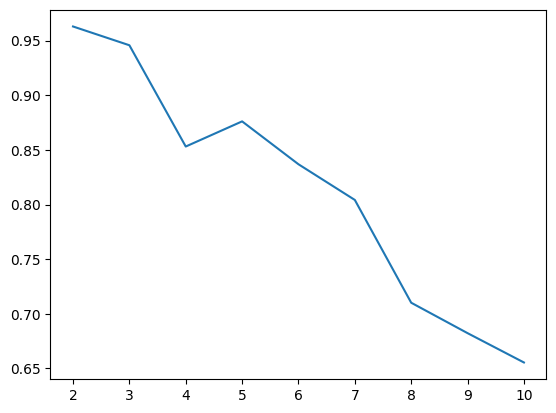

In [27]:
plt.plot(allclusters,allscore)
plt.show()

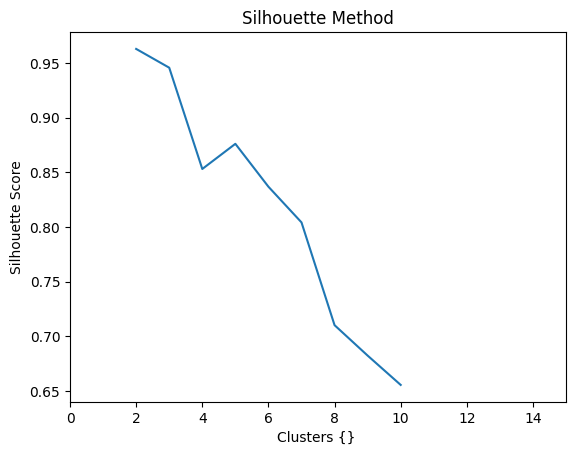

In [28]:
plt.plot(allclusters, allscore)
plt.xlabel('Clusters {} ')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.xlim(0,15)
plt.show()

In [29]:
model = KMeans(n_clusters = 4)

In [30]:
model = model.fit(x)

In [31]:
pred = model.predict(x)

In [32]:
x['Cluster'] = pred

In [33]:
x.head()

,Orders.subtotal_x,Orders.subtotal_y,Cluster
Customers.id,,,
3,88.78,2,0
4,19.56,1,0
5,95.14,3,0
7,39.19,1,0
8,59.75,1,0


In [34]:
silhouette_score(x, pred)

0.9275920807125176

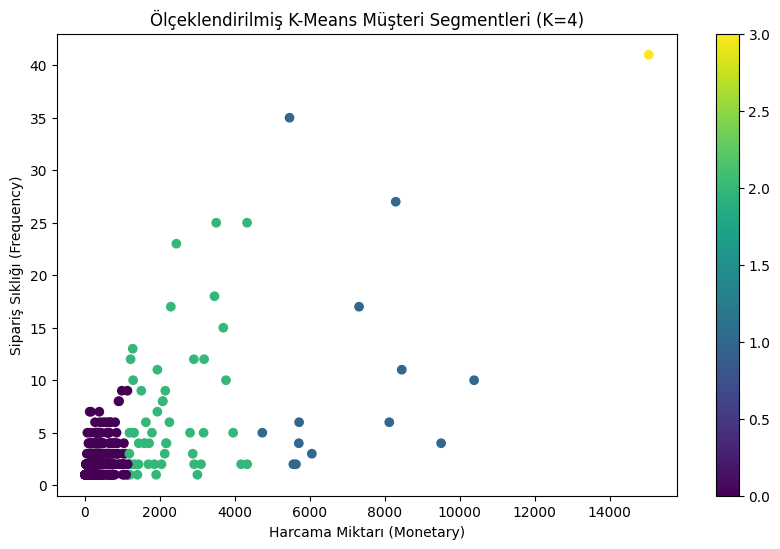

In [35]:
plt.figure(figsize = (10,6))
# 'c=x['Cluster']' ile yeni oluşturduğumuz doğru kümeleri renklendiriyoruz
plt.scatter(x['Orders.subtotal_x'], x['Orders.subtotal_y'], c=x['Cluster'], cmap='viridis')
plt.xlabel('Harcama Miktarı (Monetary)')
plt.ylabel('Sipariş Sıklığı (Frequency)')
plt.title('Ölçeklendirilmiş K-Means Müşteri Segmentleri (K=4)')
plt.colorbar()
plt.show()

In [36]:
# Modeli kuralım
model = KMeans(n_clusters = 4, random_state=42)

# Modeli x_scaled ile eğit ve tahmin yapalım
model = model.fit(x_scaled)
pred = model.predict(x_scaled)

# Kümeleri (Cluster) orijinal x tablosuna ekle ki görselleştirmede gerçek paraları görebiliriz
x['Cluster'] = pred

x.head()

,Orders.subtotal_x,Orders.subtotal_y,Cluster
Customers.id,,,
3,88.78,2,1
4,19.56,1,1
5,95.14,3,1
7,39.19,1,1
8,59.75,1,1


##### With a silhouette score of approximately 0.86, the scaled K-Means clustering model demonstrates a robust and realistic separation between customer groups. 

##### While standardizing the data (StandardScaler) slightly lowered the raw mathematical score compared to the unscaled version, it critically ensured that both **Purchasing Frequency** and **Monetary Value** were given equal weight. Instead of just grouping by spending amounts, this scaled model creates truly actionable segments (e.g., loyal high-spenders vs. one-time buyers). This provides highly valuable and realistic insights for the marketing team to optimize targeted campaigns and customer retention strategies.